In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
n_a = 3
n_b = 3
sigma_0s = [2, 3, 4]

expected_rates = np.array([n_a * n_b * sigma_0 * (0.5 if i != 2 else 1) for i, sigma_0 in enumerate(sigma_0s)])
print(expected_rates)

[ 9.  13.5 36. ]


In [ ]:
ppe_vals = np.array([10 * 2**(i) for i in range(5)])
rates = np.zeros((len(ppe_vals), 3))
errors = np.zeros_like(rates)
print(rates.shape)
for i, ppe in enumerate(ppe_vals):
    file_name = f"data/{ppe:d}_ppe.csv"
    data = pd.read_csv(f"data/{ppe:d}_ppe.csv")
    rates[i][0] = data["A_A_reaction_rate"].to_numpy()[1:].mean()
    rates[i][1] = data["B_B_reaction_rate"].to_numpy()[1:].mean()
    rates[i][2] = data["A_B_reaction_rate"].to_numpy()[1:].mean()

    errors[i] = np.abs(rates[i] - expected_rates) / expected_rates


print(rates)
print(errors)

(5, 3)
[[ 8.37     12.3      36.12    ]
 [ 8.58     12.9      36.12    ]
 [ 8.805    13.2      36.0375  ]
 [ 8.9025   13.35     36.01875 ]
 [ 8.956875 13.425    36.009375]]
[[0.07       0.08888889 0.00333333]
 [0.04666667 0.04444444 0.00333333]
 [0.02166667 0.02222222 0.00104167]
 [0.01083333 0.01111111 0.00052083]
 [0.00479167 0.00555556 0.00026042]]


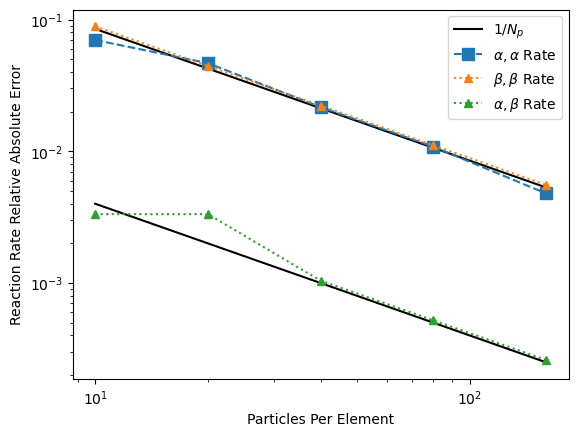

In [25]:
plt.figure()
plt.loglog(ppe_vals, 0.85 / ppe_vals, '-k', label="$1 / N_p$")
plt.loglog(ppe_vals, 4e-2 / ppe_vals, '-k')
plt.loglog(ppe_vals, np.abs(errors[:, 0]), '--s', label="$\\alpha, \\alpha$ Rate", markersize=8)
plt.loglog(ppe_vals, np.abs(errors[:, 1]), ':^', label="$\\beta, \\beta$ Rate")
plt.loglog(ppe_vals, np.abs(errors[:, 2]), ':^', label="$\\alpha, \\beta$ Rate")

plt.legend()
plt.xlabel("Particles Per Element")
plt.ylabel("Reaction Rate Relative Absolute Error")
plt.show()

In [29]:
dt_vals = [0.5**i for i in range(10)]

dt_rates = np.zeros((len(dt_vals), 3))
dt_errors = np.zeros_like(rates)
print(rates.shape)
for i, dt in enumerate(dt_vals):
    file_name = f"data/dt_{dt:0.4f}.csv"
    data = pd.read_csv(file_name)
    dt_rates[i][0] = data["A_A_reaction_rate"].to_numpy()[1:].mean()
    dt_rates[i][1] = data["B_B_reaction_rate"].to_numpy()[1:].mean()
    dt_rates[i][2] = data["A_B_reaction_rate"].to_numpy()[1:].mean()

    dt_errors[i] = np.abs(rates[i] - expected_rates) / expected_rates


print(dt_rates)
print(dt_errors)

(10, 3)
[[ 8.99925    13.4988     36.00015   ]
 [ 8.9994     13.49898    36.00054   ]
 [ 8.99976    13.49928    36.00024   ]
 [ 9.00048    13.49976    36.00144   ]
 [ 9.00096    13.50144    36.00288   ]
 [ 9.00480769 13.50288462 36.00480769]
 [ 9.00769231 13.50961538 36.00769231]
 [ 9.01538462 13.52692308 36.01923077]
 [ 9.03846154 13.53846154 36.04615385]
 [ 9.06       13.545      36.06      ]]
[[8.33333332e-05 8.88888896e-05 4.16666628e-06]
 [6.66666663e-05 7.55555551e-05 1.49999989e-05]
 [2.66666667e-05 5.33333331e-05 6.66666681e-06]
 [5.33333333e-05 1.77777779e-05 4.00000003e-05]
 [1.06666667e-04 1.06666667e-04 8.00000000e-05]
 [5.34188034e-04 2.13675214e-04 1.33547009e-04]
 [8.54700855e-04 7.12250712e-04 2.13675214e-04]
 [1.70940171e-03 1.99430199e-03 5.34188034e-04]
 [4.27350427e-03 2.84900285e-03 1.28205128e-03]
 [6.66666667e-03 3.33333333e-03 1.66666667e-03]]


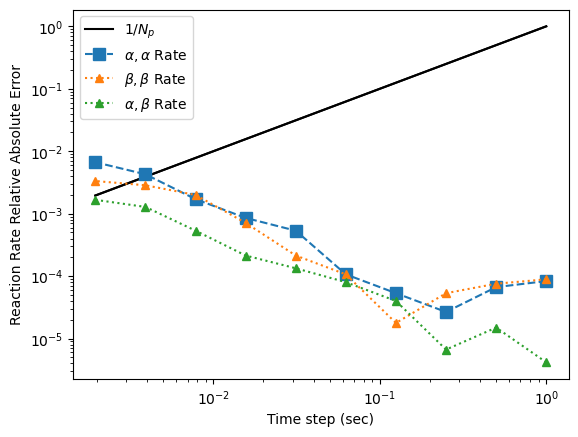

In [30]:
plt.figure()
plt.loglog(dt_vals, dt_vals, '-k', label="$1 / N_p$")
plt.loglog(dt_vals, dt_vals, '-k')
plt.loglog(dt_vals, np.abs(dt_errors[:, 0]), '--s', label="$\\alpha, \\alpha$ Rate", markersize=8)
plt.loglog(dt_vals, np.abs(dt_errors[:, 1]), ':^', label="$\\beta, \\beta$ Rate")
plt.loglog(dt_vals, np.abs(dt_errors[:, 2]), ':^', label="$\\alpha, \\beta$ Rate")

plt.legend()
plt.xlabel("Time step (sec)")
plt.ylabel("Reaction Rate Relative Absolute Error")
plt.show()